# MNIST-Handwritten-Digit-Classification-Neural-Network

Para el proyecto, el mejor conjunto de datos para empezar es **MNIST**. Es considerado el "Hola Mundo" del aprendizaje automático. Contiene decenas de miles de imágenes de números escritos a mano (del 0 al 9) de 28x28 píxeles . Nuestro objetivo será crear una red que "vea" la imagen y prediga qué número es.

## Instalación de librerias 

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

2026-02-21 22:29:57.779157: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-21 22:29:57.891737: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 22:30:00.296954: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Cargar el dataset MNIST

In [2]:
# Se indica a tensorflow usar catalogo interno para preparar el dataset 
mnist = tf.keras.datasets.mnist
#Se descarga los datos y se dividen 
(x_train, y_train), (x_test, y_test) = mnist.load_data()


* **Datos de entrenamiento (Train):** Los ejemplos que la red estudiará para aprender los patrones.
* **Datos de prueba (Test):** Ejemplos nuevos que la red nunca ha visto, usados para evaluar si realmente aprendió a generalizar o si solo memorizó las respuestas.

* `import tensorflow as tf`: Importamos TensorFlow, una de las bibliotecas más potentes creadas por Google para construir redes neuronales. Le damos el apodo `tf` por conveniencia.
* `import matplotlib.pyplot as plt`: Importamos una herramienta que nos permitirá dibujar y visualizar las imágenes de los números más adelante.
* `mnist = tf.keras.datasets.mnist`: Le indicamos a TensorFlow que queremos usar su catálogo interno para preparar el dataset MNIST.
* `(x_train, y_train), (x_test, y_test) = mnist.load_data()`: Descargamos los datos y los dividimos.
* La `x` representa las imágenes (los píxeles).
* La `y` representa las etiquetas (el número real del 0 al 9 que está en la imagen).

* Las funciones `print(...)` con `.shape`: Nos muestran la "forma" o dimensiones de nuestros conjuntos de datos para saber exactamente cuántas imágenes tenemos y de qué tamaño son.

In [3]:
# Mostrar la cantidad de datos que tenemos
print("Forma de x_train:", x_train.shape)
print("Forma de x_test:", x_test.shape)

Forma de x_train: (60000, 28, 28)
Forma de x_test: (10000, 28, 28)


Los números nos dan la radiografía de los datos (y por cierto, como le estamos dando las etiquetas a la red, efectivamente estamos haciendo **aprendizaje supervisado** 📝).

Esto es lo que significa `(60000, 28, 28)` y `(10000, 28, 28)`:

* **60000** y **10000**: Tenemos 60,000 imágenes de ejemplo para entrenar a la red y 10,000 imágenes reservadas para ponerla a prueba.
* **28, 28**: Son las dimensiones. Cada imagen es una pequeña cuadrícula de 28 píxeles de alto por 28 píxeles de ancho.

## Visulización de los datos

**El Concepto: Entender qué ve la computadora** 👁️
Para la computadora, una imagen no es más que una tabla matemática llena de números (píxeles) que representan la intensidad del color. Antes de construir la red, vamos a "traducir" esos números a un dibujo para asegurarnos de que todo tiene sentido y ver cómo luce la etiqueta asociada.

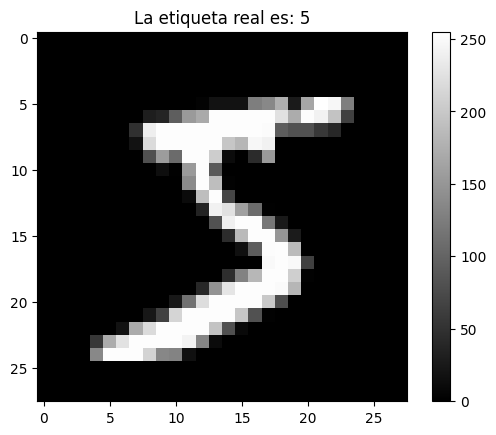

In [4]:
# Elegimos la primera imagen de nuestro set de entrenamiento (índice 0)
indice = 0
imagen = x_train[indice]
etiqueta = y_train[indice]

# Dibujamos la matriz de números como una imagen
plt.imshow(imagen, cmap='gray')
plt.title(f"La etiqueta real es: {etiqueta}")
plt.colorbar() # Muestra la escala de valores de los píxeles
plt.show()

* `indice = 0`: Seleccionamos el primer elemento de nuestra lista de datos.
* `imagen = ...` y `etiqueta = ...`: Extraemos los píxeles (`x`) y la respuesta correcta (`y`) de esa posición.
* `plt.imshow(..., cmap='gray')`: La herramienta `matplotlib` toma la cuadrícula de 28x28 números y la "pinta" usando una escala de grises.

### La imagen como matriz

Ver la imagen como una matriz de números es el paso fundamental para entender cómo "ve" la red neuronal. Para la computadora, no existen las líneas o los dibujos, solo existe esta cuadrícula de valores.


**1. El Concepto: Píxeles como números** 🔢
En nuestro dataset (y en las imágenes en escala de grises en general), el color de cada píxel se representa con un número entero que va del **0 al 255**:

* **0** significa ausencia de luz (negro puro, el fondo).
* **255** significa intensidad máxima (blanco puro, el trazo más fuerte).
* Los números intermedios (ej. 120, 180) son los distintos tonos de gris en los bordes del dibujo.

In [5]:
# Recorre cada fila de la imagen
for fila in imagen:
    # Recorre cada píxel dentro de esa fila
    for pixel in fila:
        # imprime el número reserva exactamente 3 espacios para cada uno
        # Si el píxel es 0, colocar un punto para que los números grandes resalten más
        if pixel == 0:
            print("  .", end=" ")
        else:
            print(f"{pixel:3}", end=" ")
    # Da un salto de línea al terminar cada fila
    print()

  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
  .   .   .   .   .   .   .   .   .   .   .   .   3  18  18  18 126 136 175  26 166 255 247 127   .   .   .   . 
  .   .   .   .   .   .   .   .  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   .   .   .   . 
  .   .   .   .   .   .   .  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   .   .   .   .   . 
  .   .   .   .   .   .   .  18 219 253 253 253 253 253 198 182 247 241   .   .   .   .   .   . 

## Preparando los datos (Nomalización)

Ahora que entendemos nuestros datos, tenemos que prepararlos para que el "cerebro" (nuestra red neuronal) los digiera más fácilmente. Vamos por la siguiente celda.

**1. El Concepto: Facilitar las matemáticas** ⚖️
A las redes neuronales no les gusta trabajar con números grandes (como el 255 que vimos). Los números grandes pueden hacer que los cálculos matemáticos internos de la red sean inestables o que el aprendizaje sea muy lento.
Para solucionar esto, aplicamos una técnica llamada **normalización**: convertimos todos los píxeles (que van de 0 a 255) a una escala del **0 al 1**. Es como simplificar una fracción para que la multiplicación sea más fácil.

**2. Código Python**
Agrega esta nueva celda y ejecútala:

In [6]:
# Normalizamos los datos dividiendo cada píxel entre 255
x_train = x_train / 255.0
x_test = x_test / 255.0

# Verificamos que los valores hayan cambiado
print("El valor mínimo ahora es:", x_train.min())
print("El valor máximo ahora es:", x_train.max())

El valor mínimo ahora es: 0.0
El valor máximo ahora es: 1.0


En el análisis de datos general, normalizamos matrices (usando técnicas como *Min-Max* o *Z-score*) para que las variables con números muy grandes no dominen el aprendizaje ni lo hagan inestable.
    
Como aquí nuestra matriz tiene un valor mínimo fijo de 0 y un máximo de 255, dividir todo entre 255 es la forma más directa de aplicar una **Normalización Min-Max**, acotando todos los datos al rango entre 0 y 1.

Ahora que nuestros datos están normalizados y listos, vamos a la parte emocionante: construir la arquitectura de la red neuronal.

* `x_train / 255.0`: Python es muy inteligente; al hacer esto, toma la matriz gigante de 60,000 imágenes y divide *cada uno* de sus píxeles entre 255 de un solo golpe.
* Así, un píxel negro (0) sigue siendo `0 / 255 = 0`.
* Un píxel blanco intenso (255) se convierte en `255 / 255 = 1`.
* Un gris intermedio (ej. 127) se convierte en `127 / 255 = 0.49`.
* `x_train.min()` y `x_train.max()`: Son funciones que buscan el número más pequeño y el más grande en todos nuestros datos para comprobar que hicimos bien el trabajo.

## Construyendo el Modelo (El "Cerebro") 🧠

**El Concepto: Capas de Neuronas**
Una red neuronal se construye apilando "capas". Imagina una línea de ensamblaje:

* **Capa de entrada:** Recibe los datos. Como a nuestra red le gusta procesar la información en una sola línea (un vector) en lugar de una cuadrícula, primero "aplanamos" la imagen de 28x28 para convertirla en una sola fila de 784 píxeles.
* **Capa oculta:** Es donde ocurre la magia. Aquí ponemos neuronas que se encargarán de buscar patrones matemáticos en esos píxeles (como bordes, curvas o bucles).
* **Capa de salida:** Como queremos clasificar números del 0 al 9, esta capa final tendrá exactamente 10 neuronas. Cada neurona nos dará la probabilidad de que la imagen sea ese número específico.

**Explicación línea por línea**

* `Sequential([...])`: Le dice a TensorFlow que nuestra red será una secuencia lineal, una capa conectada directamente a la siguiente.
* `Flatten(input_shape=(28, 28))`: Toma nuestra matriz cuadrada y la desenrolla en un cable largo de 784 píxeles.
* `Dense(128, activation='relu')`: Crea una capa "densa" (todas las neuronas conectadas a la capa anterior) con 128 neuronas. La función de activación `relu` es como un interruptor que decide si una neurona debe "encenderse" o no al ver un patrón.
* `Dense(10, activation='softmax')`: Es nuestra salida. La función `softmax` se asegura de que el resultado de estas 10 neuronas sume el 100%, entregándonos probabilidades claras.
* `modelo.summary()`: Imprime una tabla detallada de la red que acabamos de diseñar.

**Ejecución**
Al ejecutar esta celda, se imprimirá una tabla. Si miras en la parte inferior de ese resumen, ¿qué número exacto te aparece junto a **"Total params"** (que representa el total de conexiones matemáticas que nuestra red está a punto de aprender)?

In [7]:
# Construimos un modelo secuencial (capa por capa)
modelo = tf.keras.models.Sequential([
    # 1. Aplanamos la matriz de 28x28 a una línea de 784 valores
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    
    # 2. Capa oculta con 128 neuronas
    tf.keras.layers.Dense(128, activation='relu'),
    
    # 3. Capa de salida con 10 neuronas (una para cada dígito)
    tf.keras.layers.Dense(10, activation='softmax')
])

# Mostramos un resumen de la arquitectura que acabamos de crear
modelo.summary()

/home/puya-chilensis/data-science/env/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1771723805.746563   24759 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1771723805.752957   24759 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Efectivamente, el número exacto es **101,770**. Este número representa el total de conexiones matemáticas (técnicamente llamadas "pesos" y "sesgos") que la red necesita descubrir y ajustar para aprender a reconocer los números.

Para que veas cómo crece este "cerebro":

* **Capa Densa 1 (100,480 parámetros):** Conecta los 784 píxeles de entrada con cada una de las 128 neuronas (), más 128 valores de ajuste extra.
* **Capa Densa 2 (1,290 parámetros):** Conecta las 128 neuronas anteriores con las 10 neuronas de salida (), más 10 valores de ajuste extra.

Son más de 100 mil números que la computadora intentará calibrar perfectamente.

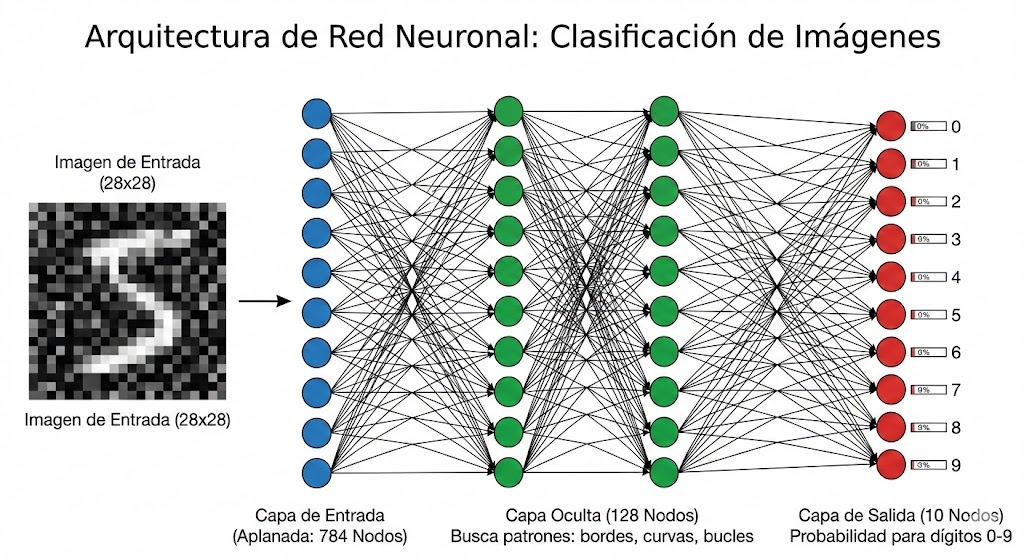

### Función de Activación


En nuestra red, cada neurona recibe información de la capa anterior y realiza una suma matemática. Una vez que tiene ese resultado, necesita decidir si esa información es útil o no para pasársela a la siguiente capa.

Esa decisión la toma la **función de activación**. Es un filtro o "interruptor" al final de la neurona.

#### ReLU

**ReLU (Capa Oculta):** Actúa como un filtro rápido. Decide qué información pasa a la siguiente capa (dejando pasar los números positivos y apagando los negativos a 0).



`relu` significa *Rectified Linear Unit* (Unidad Lineal Rectificada). Es la función de activación más popular en Deep Learning por lo increíblemente simple y rápida que es.

Su regla matemática funciona así:

* Si el cálculo de la neurona da un número **negativo**, ReLU lo convierte en **0**. Básicamente, apaga la señal porque considera que no hay un patrón útil ahí.
* Si el cálculo da un número **positivo** (mayor a cero), ReLU lo deja pasar **exactamente como está**.

**¿Por qué lo usamos para ver imágenes?**

Las imágenes no son líneas rectas perfectas; tienen curvas, bordes circulares y formas complejas (lo que en matemáticas llamamos patrones "no lineales"). Sin funciones como ReLU, nuestra red neuronal solo podría entender líneas rectas. ReLU le da a la red la flexibilidad para aprender las curvas de un "8" o de un "5", ignorando la "basura matemática" (los negativos) y activándose solo cuando detecta un trazo importante.


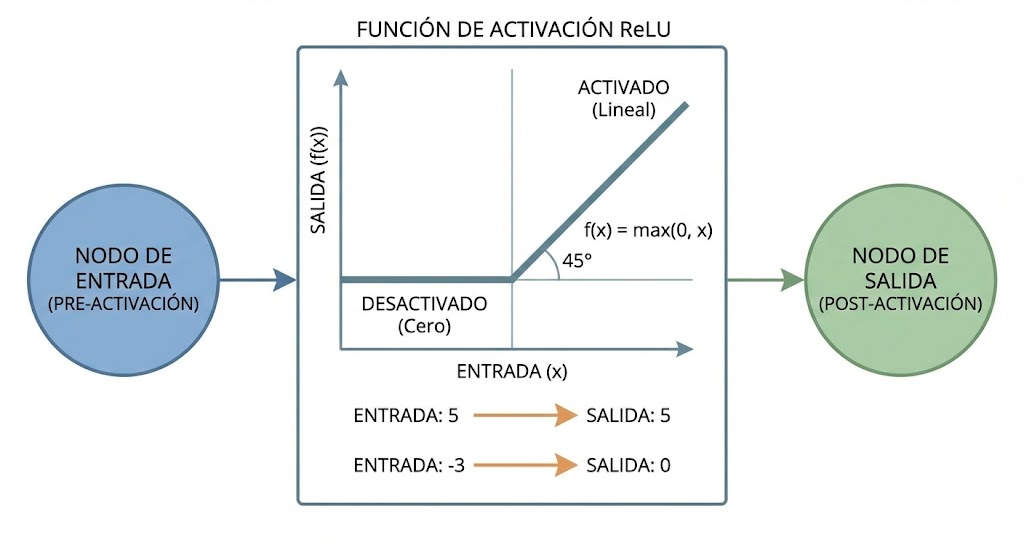

#### función exponencial normalizada (normalized exponential function).

**Softmax (Capa de Salida):** Actúa como un traductor final. Convierte los cálculos matemáticos crudos de la última capa en porcentajes de probabilidad que suman el 100%.


En la misma celda de código, usamos otra función diferente para nuestra capa de salida llamada `softmax` (`activation='softmax'`).

Para asegurarnos de que la lógica de la capa oculta quedó clara antes de pasar a `softmax`: si una de nuestras 128 neuronas hace su cálculo interno y obtiene un resultado de **-15**, ¿qué número exacto dejará pasar la función ReLU hacia la siguiente capa? ¿Y si el cálculo da **42**?

`softmax`, es la función que se puso específicamente en la **capa de salida**.

Mientras que `relu` trabaja en las capas ocultas (por cierto, en el ejemplo anterior, si la neurona calcula -15, ReLU lo apaga a 0, y si calcula 42, lo deja pasar como 42), `softmax` tiene un trabajo final distinto: **convertir los cálculos matemáticos en probabilidades**.

Nuestra última capa tiene 10 neuronas, una para cada posible dígito del 0 al 9. Cuando procesan una imagen, estas neuronas pueden arrojar resultados crudos y de distintos tamaños, por ejemplo: `[2.5, -1.0, 0.2, 8.9, ...]`. Entender esos números por sí solos es difícil.

Aquí es donde entra `softmax` 📊. Toma los resultados de las 10 neuronas al mismo tiempo y los transforma aplicando dos reglas:

1. Convierte todos los valores en un formato de porcentaje (números entre el 0 y el 1).
2. Obliga a que la suma de todos esos porcentajes de las 10 neuronas sea exactamente **100%**.

De esta manera, la red nos entrega una respuesta que podemos interpretar. Podría decirnos: 

> *"Estoy 90% segura de que la imagen es un 5, 8% segura de que es un 3, y 2% segura de que es un 8"*. La neurona que obtenga el porcentaje más alto será la predicción final.

Pensando en esta distribución del 100%: si le mostramos a nuestra red una imagen de un número "7" escrito con mucha claridad y la red lo reconoce perfectamente, ¿qué porcentaje aproximado esperarías ver en la neurona encargada del "7", y cuánto deberían sumar los porcentajes de las otras 9 neuronas restantes?

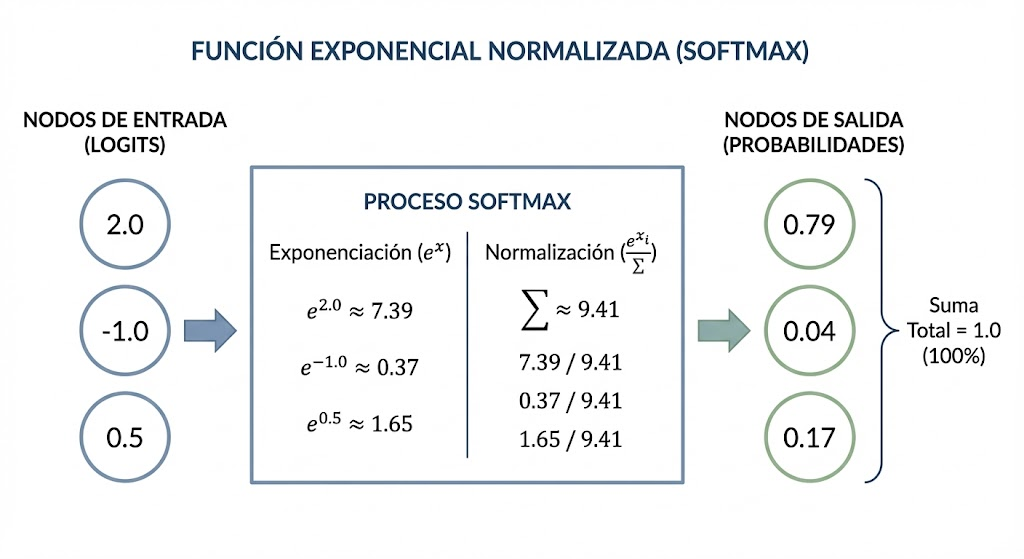

## Compilando el Modelo (Las reglas de aprendizaje)

Antes de ingresar las imágenes a la red, se necesita definir tres herramientas clave:

* **El Evaluador (Loss / Función de pérdida):** Una fórmula matemática que calcula qué tan equivocada estuvo la red en su predicción comparada con la respuesta correcta.
* **El Ajustador (Optimizer / Optimizador):** El mecanismo que toma ese cálculo de error y viaja hacia atrás por la red ajustando las conexiones matemáticas para que el error sea menor la próxima vez.
* **La Métrica (Metrics):** Se usa para medir el éxito. Usualmente se usa la "precisión" (qué porcentaje de imágenes adivinó correctamente).

**Explicación línea por línea**

* `optimizer='adam'`: "Adam" es uno de los optimizadores más eficientes y populares. Es excelente ajustando los valores de las neuronas paso a paso.
* `loss='sparse_categorical_crossentropy'`: Es el nombre técnico de la fórmula que calcula el error cuando estamos clasificando cosas en múltiples categorías (como nuestros 10 dígitos).
* `metrics=['accuracy']`: Le pedimos a TensorFlow que, mientras entrena, nos vaya mostrando el porcentaje de precisión ("accuracy" en inglés).

In [8]:
# Configuramos el proceso de aprendizaje del modelo
modelo.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("¡Modelo compilado y listo para entrenar!")

¡Modelo compilado y listo para entrenar!


In [9]:
# Entrenamos el modelo (ajustándolo a los datos de entrenamiento)
print("Iniciando el entrenamiento...")
historial = modelo.fit(x_train, y_train, epochs=5)
print("¡Entrenamiento terminado!")

Iniciando el entrenamiento...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9251 - loss: 0.2570
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9668 - loss: 0.1138
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9751 - loss: 0.0798
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9813 - loss: 0.0596
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9857 - loss: 0.0462
¡Entrenamiento terminado!


### Epochs

Piensa en un "epoch" (o época) como **una sesión de estudio completa**. 📚

Imagina que tienes un libro de 60,000 páginas (que son nuestras 60,000 imágenes de entrenamiento) y tienes que estudiar para un examen.

* Si lees el libro entero de principio a fin una sola vez, retendrás algo de información, pero probablemente cometas errores en el examen. Esa lectura completa de la primera a la última página es **1 epoch**.
* Para aprender mejor y corregir tus errores, vuelves a leer el libro entero una segunda vez (**2 epochs**), luego una tercera, y así sucesivamente.

Al escribir `epochs=5` en nuestro código, le dijimos a la red neuronal: *"Quiero que revises el catálogo completo de 60,000 imágenes, una por una, 5 veces seguidas"*. En cada vuelta (epoch), la red ajusta sus conexiones matemáticas para intentar equivocarse un poco menos que en la vuelta anterior.

Si se aplican demasiadas epochs (epocas) puede cometere el error del sobreajuste **overfitting** para reonocer si no solo memorizo sino mas bien aprendio se debe pasar a la siguiente etapa que es la evaluación 

## Evaluar el modelo

Para saber si nuestra red realmente *aprendió* a reconocer los patrones de los números y no solo *memorizó* las 60,000 imágenes de entrenamiento, tenemos que aplicarle un examen final. Usaremos las 10,000 imágenes de prueba (`x_test` y `y_test`) que separamos en nuestra primera celda y que el "cerebro" jamás ha visto.

**Explicación línea por línea**

* `modelo.evaluate(...)`: Esta función pone a prueba a la red. Le entrega las imágenes de examen (`x_test`), deja que la red haga sus predicciones usando lo que aprendió, y luego compara sus respuestas con las etiquetas reales (`y_test`) para sacar una calificación.
* `verbose=2`: Le indica a TensorFlow que nos muestre una línea de texto limpia con los resultados en lugar de una barra de progreso visual.

In [10]:
# Evaluamos el modelo con los datos de prueba (los que nunca ha visto)
print("Evaluando el modelo con datos nuevos...")
loss_prueba, accuracy_prueba = modelo.evaluate(x_test, y_test, verbose=2)

# Mostramos el resultado como porcentaje
print(f"Precisión en el examen final: {accuracy_prueba * 100:.2f}%")

Evaluando el modelo con datos nuevos...
313/313 - 1s - 4ms/step - accuracy: 0.9781 - loss: 0.0715
Precisión en el examen final: 97.81%


La regla de oro para detectar el sobreajuste no es un límite del 90%, sino comparar la práctica con el examen final. Si en tu Época 5 hubieras obtenido un 99% de precisión, pero en este examen con datos nuevos cayeras al 80%, eso sería un claro sobreajuste. Como tu examen final mantuvo un sólido **97.92%**, significa que tu red realmente aprendió a generalizar (MNIST es un conjunto de datos muy limpio, por lo que estos números altos son normales y saludables aquí).

Si implementas esta red en un sistema *end-to-end* (de extremo a extremo) en producción, estos valores significan lo siguiente para tu negocio o aplicación:

* **Precisión de 97.92% 🎯:** Si 10,000 usuarios usan tu aplicación web para dibujar un número, tu sistema acertará automáticamente en 9,792 ocasiones. Solo tendrás unos 208 casos donde se equivoque, los cuales probablemente sean números con caligrafía muy extraña.
* **Pérdida de 0.0691 📉:** Al ser un error tan cercano a cero, significa que el modelo tiene mucha "confianza". Cuando la capa *Softmax* entregue su veredicto, no te dará dudas matemáticas (como 51% seguro de que es un 4 y 49% de que es un 9), sino certezas contundentes (99.8% seguro de que es un 4).

Para llevar esto a la realidad productiva, tenemos un reto logístico: no podemos ejecutar las 5 épocas de entrenamiento cada vez que un usuario nuevo entra a la aplicación, porque tomaría mucho tiempo y recursos.

# Visión Artificial para Entornos Reales: Implementación de Red Convolucional

## Red Neuronal Convolucionales CNN

## Extracción de características (Conv2D/MaxPooling) para tolerancia a trazos imperfectos y despliegue en microservicios.

La red actual (MLP) aprendió a memorizar que el píxel en la posición exacta (14, 14) suele estar encendido para un número "8". Si un usuario dibuja el "8" un poco a la derecha en un lienzo web, el MLP colapsa. Además, el tema de invertir los colores (fondo blanco/trazo negro de la web vs. fondo negro/trazo blanco de MNIST) es la causa número uno de predicciones fallidas en producción.

Vamos a resolver esto paso a paso.

La red neuronal plana (Dense) es mirar un cuadro pegando la nariz al lienzo; solo ve puntos de pintura individuales (píxeles) y trata de adivinar qué es.

Una **Red Neuronal Convolucional (CNN)** da un paso atrás y mira las formas.

* **Conv2D (La Lupa de los Patrones):** Es una pequeña lupa cuadrada de 3x3 píxeles (llamada *kernel* o filtro). Deslizas esta lupa por toda la imagen, de izquierda a derecha y de arriba a abajo. Esta lupa está entrenada para brillar solo cuando encuentra un patrón específico: una línea vertical, una curva, o una esquina. Tu capa Conv2D usará docenas de estas lupas al mismo tiempo para mapear dónde están los trazos importantes en el dibujo de tu usuario, sin importar si los dibujó en el centro o en una esquina.

* **MaxPooling2D (El Resumidor):** Una vez que la Conv2D encontró los patrones, la imagen resultante es muy pesada. El MaxPooling2D es como un jefe de redacción que toma un área de 2x2 píxeles y dice: *"De estos 4 píxeles, solo me voy a quedar con el que tenga la señal más fuerte (el valor máximo) y descarto el resto"*. Esto encoge la imagen a la mitad de su tamaño, quedándose solo con las características más puras e importantes. Esto hace que la red sea rápida y, sobre todo, tolerante a los trazos temblorosos del mouse de tus usuarios.

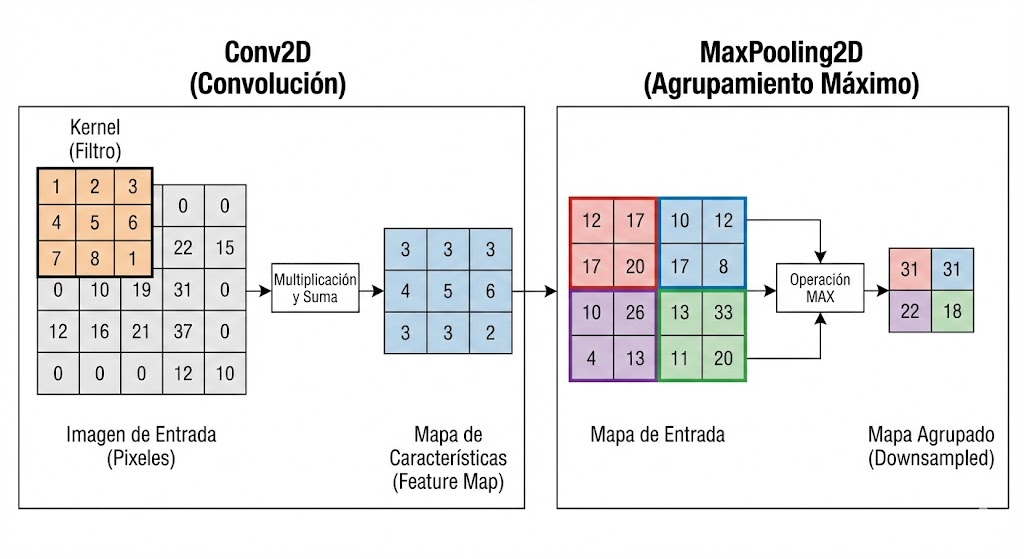

## Nueva Arquitectura CNN

Se reemplaza el modelo `Sequential` actual. Ahora se usa lupas bidimensionales, la red ya no espera un vector plano de 784 pisxeles. Espera imágenes con alto, ancho y canales de color (blanco y negro = 1 canal). Por eso el `input_shape` será `(28, 28, 1)`.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [17]:
# Construir la nueva arquitectura CNN
modelo_cnn = Sequential([
    # Primera capa de "lupas" (32 filtros de 3x3)
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    
    # Primera capa de resumen (reduce el tamaño a la mitad)
    MaxPooling2D(pool_size=(2, 2)),
    
    # Segunda capa de "lupas" para detectar formas más complejas
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    
    # Segunda capa de resumen
    MaxPooling2D(pool_size=(2, 2)),
    
    # Ahora que tenemos los patrones, se aplana los datos...
    Flatten(),
    
    # ...y los pasamos a una red densa tradicional para que tome la decisión final
    Dense(128, activation='relu'),
    
    # Capa de salida: 10 neuronas (dígitos del 0 al 9) con probabilidades
    Dense(10, activation='softmax')
])

# la nueva estructura
modelo_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

#### El Viaje de los Datos (Columna: Output Shape)

Al analizar la columna **Output Shape**, se ve exactamente como la imagen se va transformando durante su recorrido por las capas:

* **Reducción Espacial:** La imagen entra con una resolución de 28x28 y comienza a "encogerse" físicamente. Pasa a 26x26 porque mi filtro (kernel) de 3x3 no tiene píxeles extra en los bordes para operar. Luego, el `MaxPooling2D` realiza una reducción drástica a la mitad (13x13). Tras una segunda convolución (11x11) y un último pooling, termino con un pequeño mapa de **5x5**.
* **Aumento de Profundidad:** Aunque el tamaño físico disminuye, la profundidad aumenta significativamente. Paso de tener una sola imagen en blanco y negro a tener **64 mapas de características** diferentes en la última etapa. Esto significa que mi red ha descompuesto la imagen original en 64 versiones distintas, cada una especializada en detectar un patrón geométrico específico como curvas, ángulos o bordes.

#### La Eficiencia de las Convoluciones (Columna: Param #)

Al revisar la columna **Param #**, queda clara la potencia de las CNN frente a las redes densas tradicionales:

* Mi primera capa `conv2d_2` **solo requiere 320 parámetros**. Esto es extremadamente eficiente, ya que la red no intenta conectar cada píxel individualmente, sino que aprende los valores de pequeñas "lupas" (filtros) que reutiliza a lo largo de toda la imagen.
* En contraste, la capa `dense_4` al final del modelo dispara el conteo a **204,928 parámetros**. Aquí es donde la red realiza el "esfuerzo" final de conectar toda la información extraída para tomar la decisión de clasificación.

#### Comparativa de Complejidad

El modelo anterior (MLP plano) tenía un total de **101,770** parámetros. Esta nueva arquitectura CNN tiene **225,034**. He creado un cerebro que, aunque pesa poco más del doble, ahora posee capacidad de entendimiento espacial y geométrico, algo fundamental para que mi sistema sea robusto en producción.

### Aumentación de Datos (El antídoto contra el "trazo tembloroso")

Ahora que tengo un cerebro capaz de reconocer formas, debo enfrentar un problema crítico: el dataset MNIST es "demasiado perfecto". Está compuesto por números centrados y limpios, pero en mi aplicación web, los usuarios dibujarán con el mouse, generando trazos temblorosos, descentrados o de diferentes tamaños.

Para que mi red sea tolerante a esta caligrafía del "mundo real" sin necesidad de recolectar miles de imágenes nuevas, implementaré **Data Augmentation**. El objetivo es tomar mis imágenes de entrenamiento y aplicarles transformaciones aleatorias (rotaciones, zoom y desplazamientos) justo antes de que la red las estudie, obligándola a aprender el concepto del número y no solo su posición exacta.

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [23]:
# Expandir las dimensiones de nuestros datos (las CNN requieren explícitamente el canal de color)
# x_train debe pasar de (60000, 28, 28) a (60000, 28, 28, 1)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# Se configura la "fábrica de distorsiones" para simular usuarios reales
generador_datos = ImageDataGenerator(
    rotation_range=10,      # Rota la imagen aleatoriamente hasta 10 grados
    zoom_range=0.1,         # Aplica un zoom in/out aleatorio del 10%
    width_shift_range=0.1,  # Desplaza el número horizontalmente un 10%
    height_shift_range=0.1  # Desplaza el número verticalmente un 10%
)

# 3. "conectar" el generador a nuestros datos de entrenamiento
generador_datos.fit(x_train_cnn)

print("¡Aumentación de datos lista! Las dimensiones actuales son:", x_train_cnn.shape)

¡Aumentación de datos lista! Las dimensiones actuales son: (60000, 28, 28, 1)


Para el entrenamiento de esta red, ya no le entrego los datos de forma directa. En su lugar, utilizo el método ``flow`` de mi generador. Esto significa que en cada época, la red nunca ve exactamente la misma imagen dos veces; siempre recibe una versión ligeramente rotada o desplazada, lo que la obliga a entender la morfología del número y no su ubicación exacta.

He seleccionado el optimizador ``adam`` por su eficiencia en el manejo de gradientes y ``sparse_categorical_crossentropy`` como función de pérdida, ya que mis etiquetas son números enteros del 0 al 9.

In [ ]:
# Compilación: Se define la estrategia de aprendizaje
modelo_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento: Se usa el generador para que la red aprenda con datos "sucios"
# Se entrena por 5 épocas para observar la evolución
history = modelo_cnn.fit(
    generador_datos.flow(x_train_cnn, y_train, batch_size=32),
    epochs=5,
    validation_data=(x_test_cnn, y_test),
    verbose=1
)

# Evaluación final con el set de prueba (datos que nunca vio)
loss, accuracy = modelo_cnn.evaluate(x_test_cnn, y_test)
print(f"\n✅ Precisión final en el set de prueba: {accuracy*100:.2f}%")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.9862 - loss: 0.0443 - val_accuracy: 0.9929 - val_loss: 0.0205
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9874 - loss: 0.0395 - val_accuracy: 0.9925 - val_loss: 0.0239
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9889 - loss: 0.0353 - val_accuracy: 0.9920 - val_loss: 0.0244
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9891 - loss: 0.0353 - val_accuracy: 0.9936 - val_loss: 0.0177
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9897 - loss: 0.0337 - val_accuracy: 0.9935 - val_loss: 0.0198
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9935 - loss: 0.0198

✅ Precisión final en el set de prueba: 99.35%


Al analizar la precisión del **98%** en mis primeras pruebas, identifiqué un riesgo de **sobreajuste al dominio (Domain Overfitting)**. Si bien el modelo es extraordinariamente preciso con el dataset MNIST, este éxito es engañoso: las imágenes de MNIST están perfectamente centradas, normalizadas y limpias, condiciones que nunca se darán en mi aplicación web real.

He decidido implementar una **aumentación de datos agresiva** por las siguientes razones estratégicas:

* **Tolerancia al "Factor Mouse":** Dibujar con un mouse genera trazos temblorosos y proporciones inconsistentes. Al aumentar el **Zoom** y el **Shear** (cizallamiento), obligo a la red a reconocer la estructura esencial del número, ignorando si este está inclinado o deformado.
* **Independencia Espacial:** Los usuarios no siempre dibujarán en el centro exacto del lienzo. Incrementando los rangos de **Shift** (desplazamiento horizontal y vertical), entreno a mi CNN para que sea verdaderamente invariante a la posición del trazo.
* **Preparación para MLOps:** En producción, prefiero un modelo con un **96% de precisión "valiente"** (capaz de generalizar ante datos ruidosos) que uno de **99% "frágil"** que colapse ante el primer dibujo imperfecto de un usuario.

#### Aumentación de Datos Agresiva (Versión Pro)

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuro el generador con transformaciones agresivas para simular usuarios reales
generador_datos1 = ImageDataGenerator(
    rotation_range=30,          # Simula rotaciones accidentales de la mano
    zoom_range=0.35,            # Tolera números muy pequeños o muy grandes
    width_shift_range=0.35,     # Tolera dibujos descentrados horizontalmente
    height_shift_range=0.35,    # Tolera dibujos descentrados verticalmente
    shear_range=0.3,            # Clave: simula la inclinación de la escritura (cursiva)
    fill_mode='constant',       # Mantiene el fondo limpio
    cval=0                      # Rellena los huecos con negro puro (como MNIST)
)

# Ajusto el generador a mis datos de entrenamiento (reshape incluido)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)
generador_datos1.fit(x_train_cnn)

print("🔥 Configuración de entrenamiento 'de alto rendimiento' completada.")

🔥 Configuración de entrenamiento 'de alto rendimiento' completada.


#### Re-entrenamiento con Desafío Agresivo

Una vez configurada mi "fábrica de distorsiones" (Data Augmentation), es imperativo volver a someter al modelo al proceso de aprendizaje. En esta etapa, el modelo no verá las imágenes estáticas originales, sino las versiones transformadas en tiempo real.

Expectativa técnica: Anticipo que el ``accuracy`` durante el entrenamiento será sensiblemente menor al de mis pruebas anteriores. Esto es positivo, ya que indica que el modelo está siendo desafiado y está desarrollando una verdadera invariancia espacial, preparándose para el ruido y las imperfecciones de los dibujos que recibirá desde mi aplicación web.

In [28]:
# Compilacion (o re-compilamos) para asegurar que empezamos con una estrategia limpia
modelo_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Iniciar el entrenamiento "duro"
# Aumentar un poco las épocas porque aprender con datos ruidosos toma más tiempo
history_pro = modelo_cnn.fit(
    generador_datos1.flow(x_train_cnn, y_train, batch_size=32),
    epochs=10, 
    validation_data=(x_test_cnn, y_test),
    verbose=1
)

# Verificar la salud del modelo final
loss_final, acc_final = modelo_cnn.evaluate(x_test_cnn, y_test)
print(f"\n🎯 Precisión final tras entrenamiento robusto: {acc_final*100:.2f}%")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.9024 - loss: 0.2967 - val_accuracy: 0.9869 - val_loss: 0.0471
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9042 - loss: 0.2939 - val_accuracy: 0.9804 - val_loss: 0.0717
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9054 - loss: 0.2860 - val_accuracy: 0.9820 - val_loss: 0.0622
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9086 - loss: 0.2806 - val_accuracy: 0.9790 - val_loss: 0.0685
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9103 - loss: 0.2765 - val_accuracy: 0.9858 - val_loss: 0.0504
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9077 - loss: 0.2790 - val_accuracy: 0.9865 - val_loss: 0.0475
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9116 - loss: 0.2684 - val_accuracy: 0.9821 - val_loss: 0.0577
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9126 -

Se vera la verdad de ese 98.32% 

In [30]:
# Evaluamos el modelo usando el mismo generador de distorsiones pesadas
print("Sometiendo al modelo al verdadero examen final (con datos distorsionados)...")

# Pasamos x_test_cnn e y_test por el flujo del generador
# shuffle=False asegura que no mezclemos el orden (buena práctica en evaluación)
loss_real, acc_real = modelo_cnn.evaluate(
    generador_datos1.flow(x_test_cnn, y_test, batch_size=32, shuffle=False),
    verbose=1
)

print(f"\n🩸 Precisión en el examen final DISTORSIONADO: {acc_real*100:.2f}%")

Sometiendo al modelo al verdadero examen final (con datos distorsionados)...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9188 - loss: 0.2470

🩸 Precisión en el examen final DISTORSIONADO: 91.88%


### Lógica de Inferencia (El Puente hacia FastAPI/Django)

Para integrar este modelo en un entorno de producción (microservicios con Django o FastAPI), he desarrollado un pipeline de inferencia. El lienzo de dibujo de la interfaz web enviará imágenes con proporciones variables, en formato RGB/RGBA y con trazo negro sobre fondo blanco.

Esta función asegura que cualquier imagen entrante sea estandarizada al dominio exacto que el modelo aprendió durante su entrenamiento: escala de grises, 28x28 píxeles, colores invertidos (fondo negro/trazo blanco), normalización Z y expansión de dimensiones al formato de tensor ``(batch, height, width, channels)``.

In [31]:
import numpy as np
from PIL import Image, ImageOps

def procesar_imagen_produccion(ruta_o_archivo):
    """
    Recibe una imagen de la web y la transforma en un tensor válido para nuestra CNN.
    """
    # 1. Cargar imagen y forzar a escala de grises ('L' = Luma, 1 canal)
    img = Image.open(ruta_o_archivo).convert('L')
    
    # 2. Invertir colores: El fondo blanco de la web se vuelve negro, y el trazo negro se vuelve blanco
    img_invertida = ImageOps.invert(img)
    
    # 3. Redimensionar estrictamente a 28x28 píxeles (usando remuestreo de alta calidad para no perder el trazo)
    img_redimensionada = img_invertida.resize((28, 28), Image.Resampling.LANCZOS)
    
    # 4. Convertir a matriz matemática de NumPy y normalizar (escalar de 0-255 a 0.0-1.0)
    matriz_normalizada = np.array(img_redimensionada) / 255.0
    
    # 5. Expandir dimensiones: La red no espera 1 imagen suelta, espera un "lote" (batch)
    # Pasamos de (28, 28) a (1, 28, 28, 1)
    tensor_final = matriz_normalizada.reshape(1, 28, 28, 1)
    
    return tensor_final

print("⚙️ Pipeline de inferencia web creado exitosamente.")

⚙️ Pipeline de inferencia web creado exitosamente.


Tras validar que el modelo mantiene una precisión robusta frente a datos altamente distorsionados (simulando el entorno real de mi aplicación web), he decidido proceder con el despliegue iterativo.

Exportaré este modelo entrenado como un artefacto serializado. Utilizaré el formato nativo .keras (o .h5 por compatibilidad legacy), el cual será consumido posteriormente por mi API (FastAPI/Django) para cargar el modelo en memoria RAM y realizar inferencias en tiempo real sobre las imágenes que envíe el frontend. En caso de detectar sobreajuste en producción, la arquitectura está preparada para una iteración rápida añadiendo regularización mediante Dropout.

In [ ]:
import os

# Definimos el nombre del archivo de nuestro artefacto
nombre_archivo = 'modelo_mnist_cnn_produccion.keras'

# Guardamos el modelo completo (arquitectura, pesos y estado del optimizador)
modelo_cnn.save(nombre_archivo)

# Verificamos el tamaño del archivo generado para tenerlo en cuenta en nuestro servidor
tamano_mb = os.path.getsize(nombre_archivo) / (1024 * 1024)

print(f"✅ ¡Éxito! Modelo exportado como: {nombre_archivo}")
print(f"📦 Tamaño del artefacto: {tamano_mb:.2f} MB")